# 01 — Demographic Analysis

**Goal:** Understand how demographic factors relate to shopping preference.

**Questions we answer here:**
- How does shopping preference distribute across gender?
- Does city tier (1/2/3) influence online vs store preference?
- Which age groups prefer online vs in-store shopping?
- Does income level drive shopping channel preference?

**Input:** `data/raw/consumer_shopping_2026.csv`
**Output:** charts saved to `docs/`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/raw/consumer_shopping_2026.csv')
sns.set_theme(style='whitegrid')

colors = {'Store': '#378ADD', 'Online': '#D85A30', 'Hybrid': '#1D9E75'}

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Data loaded: 11,789 rows × 25 columns


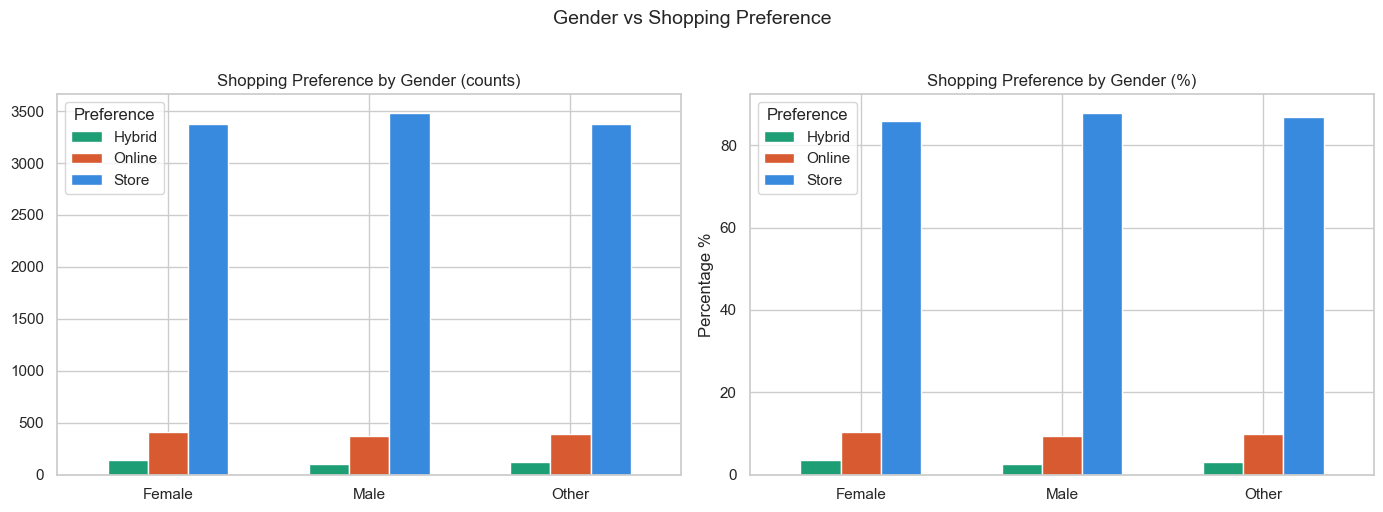

In [2]:
gender_pref = df.groupby(['gender', 'shopping_preference']).size().unstack()
gender_pref_pct = gender_pref.div(gender_pref.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_pref.plot(kind='bar', ax=axes[0], color=[colors[c] for c in gender_pref.columns],
                 width=0.6, edgecolor='white')
axes[0].set_title('Shopping Preference by Gender (counts)', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_xticklabels(gender_pref.index, rotation=0)
axes[0].legend(title='Preference')

gender_pref_pct.plot(kind='bar', ax=axes[1], color=[colors[c] for c in gender_pref_pct.columns],
                     width=0.6, edgecolor='white')
axes[1].set_title('Shopping Preference by Gender (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_xticklabels(gender_pref_pct.index, rotation=0)
axes[1].set_ylabel('Percentage %')
axes[1].legend(title='Preference')

plt.suptitle('Gender vs Shopping Preference', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/gender_vs_preference.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 2 — Gender vs Shopping Preference

### Finding
Gender has no meaningful influence on shopping preference.
All three groups show nearly identical distribution:
- Store: ~85% across all genders
- Online: ~10% across all genders  
- Hybrid: ~3% across all genders

### Business insight
**Do not segment marketing campaigns by gender for channel preference.**
Gender-based targeting (e.g. "push online ads to females") 
would be ineffective — the behavior is identical across groups.
Focus instead on behavioral and psychological factors (tech_savvy_score,
need_touch_feel_score) which showed actual predictive power in notebook 03.

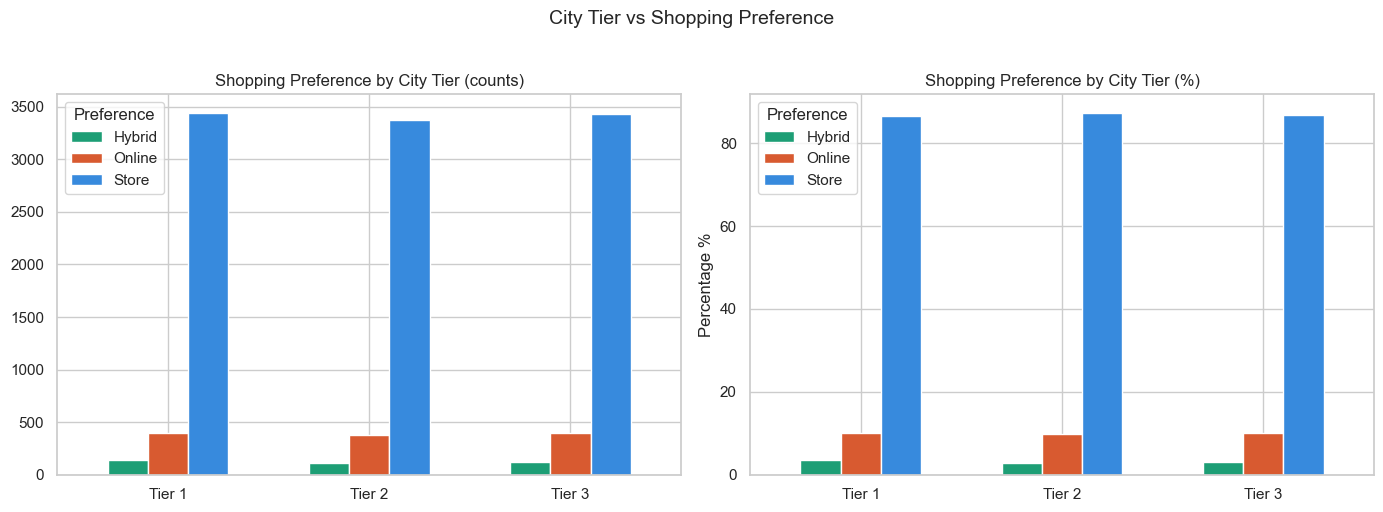

In [3]:
tier_pref = df.groupby(['city_tier', 'shopping_preference']).size().unstack()
tier_pref_pct = tier_pref.div(tier_pref.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_pref.plot(kind='bar', ax=axes[0],
               color=[colors[c] for c in tier_pref.columns],
               width=0.6, edgecolor='white')
axes[0].set_title('Shopping Preference by City Tier (counts)', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_xticklabels(tier_pref.index, rotation=0)
axes[0].legend(title='Preference')

tier_pref_pct.plot(kind='bar', ax=axes[1],
                   color=[colors[c] for c in tier_pref_pct.columns],
                   width=0.6, edgecolor='white')
axes[1].set_title('Shopping Preference by City Tier (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_xticklabels(tier_pref_pct.index, rotation=0)
axes[1].set_ylabel('Percentage %')
axes[1].legend(title='Preference')

plt.suptitle('City Tier vs Shopping Preference', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/citytier_vs_preference.png', dpi=150, bbox_inches='tight')
plt.show()


## 📊 Cell 3 — City Tier vs Shopping Preference

### Finding
City tier has no meaningful influence on shopping preference.
All three tiers show nearly identical distribution:
- Tier 1 (big city): ~86% Store, ~10% Online, ~3% Hybrid
- Tier 2 (mid city): ~87% Store, ~9% Online, ~3% Hybrid
- Tier 3 (small town): ~86% Store, ~10% Online, ~3% Hybrid

### Business insight
**Geography does not drive channel preference in this dataset.**
The assumption that small-town customers shop online more due to
fewer physical stores nearby is NOT supported by this data.

### Pattern emerging
Two demographic features tested — gender and city tier — both show
zero influence on shopping preference. This strongly suggests that
**shopping preference is driven purely by behavioral and psychological
factors**, not by who you are or where you live.

This will be confirmed in the next two cells (age and income).

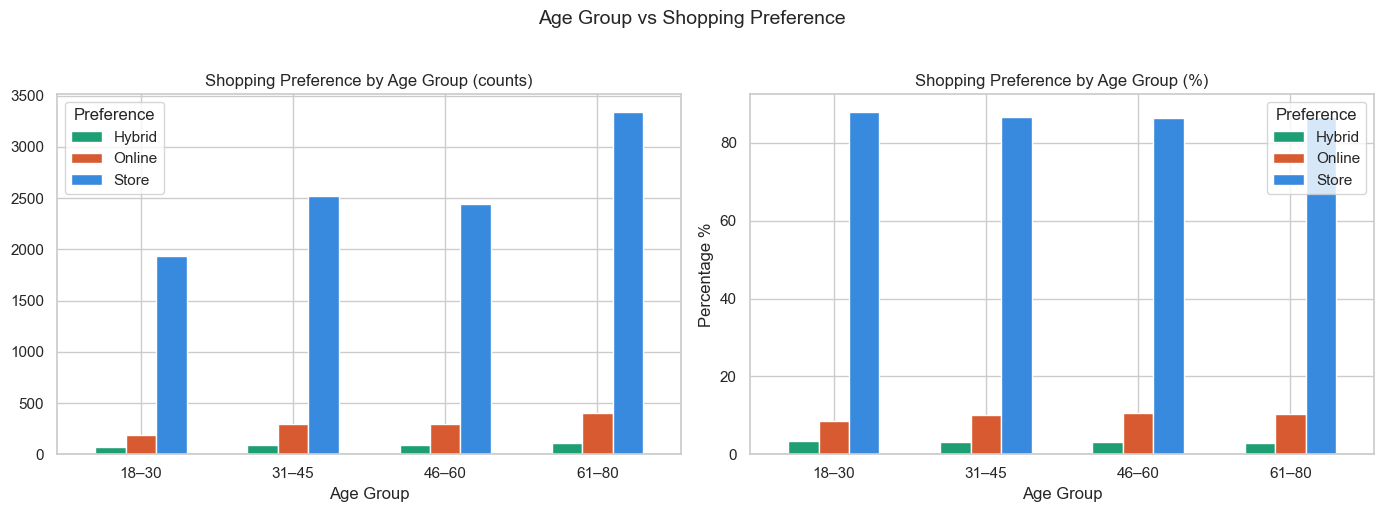

In [4]:
bins = [18, 30, 45, 60, 80]
labels = ['18–30', '31–45', '46–60', '61–80']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_pref = df.groupby(['age_group', 'shopping_preference'],
                      observed=True).size().unstack()
age_pref_pct = age_pref.div(age_pref.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_pref.plot(kind='bar', ax=axes[0],
              color=[colors[c] for c in age_pref.columns],
              width=0.6, edgecolor='white')
axes[0].set_title('Shopping Preference by Age Group (counts)', fontsize=12)
axes[0].set_xlabel('Age Group')
axes[0].set_xticklabels(age_pref.index, rotation=0)
axes[0].legend(title='Preference')

age_pref_pct.plot(kind='bar', ax=axes[1],
                  color=[colors[c] for c in age_pref_pct.columns],
                  width=0.6, edgecolor='white')
axes[1].set_title('Shopping Preference by Age Group (%)', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_xticklabels(age_pref_pct.index, rotation=0)
axes[1].set_ylabel('Percentage %')
axes[1].legend(title='Preference')

plt.suptitle('Age Group vs Shopping Preference', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/age_vs_preference.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 4 — Age Group vs Shopping Preference

### Finding
Age group has minimal influence on shopping preference.
All four groups show similar distribution (~85% Store, ~10% Online).

### Subtle pattern worth noting
Older customers (46–60, 61–80) show a very slight increase
in Online preference compared to younger customers (18–30).
This is consistent with notebook 02 findings where online shoppers
had a mean age of 49.79 vs store shoppers at 48.64.

### Business insight
**"Young people shop online" is a myth in this dataset.**
Age is not a reliable predictor of shopping channel preference.
A 65-year-old tech-savvy customer is more likely to shop online
than a 22-year-old with low tech_savvy_score.

Behavioral factors (tech_savvy_score, monthly_online_orders)
are far stronger predictors than demographic age.

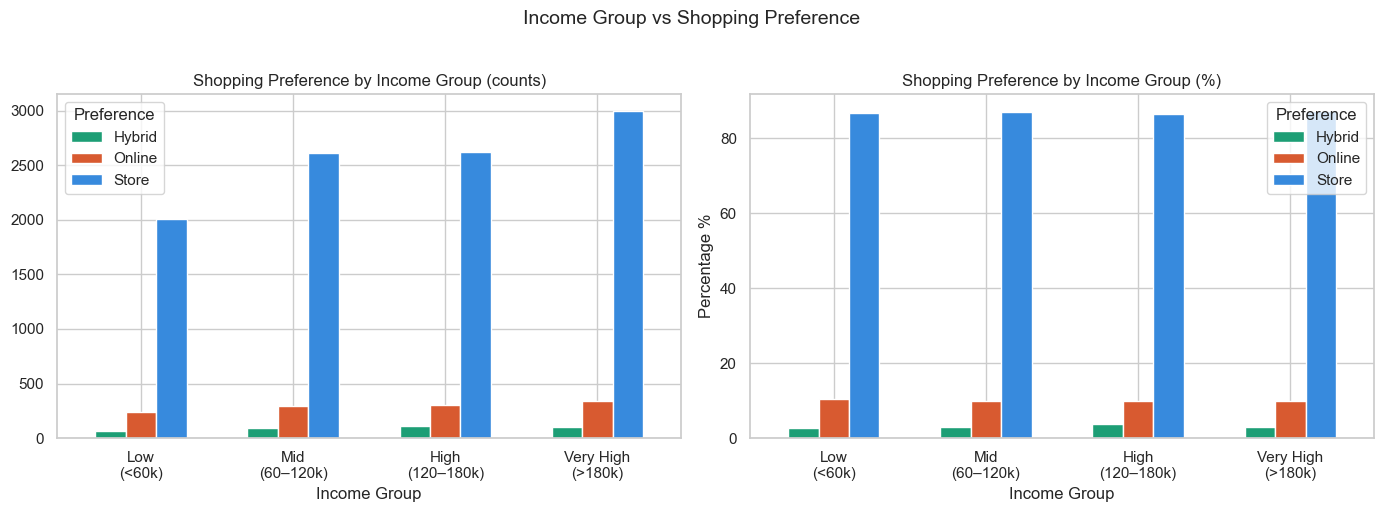

In [5]:
income_bins = [0, 60000, 120000, 180000, 250000]
income_labels = ['Low\n(<60k)', 'Mid\n(60–120k)', 'High\n(120–180k)', 'Very High\n(>180k)']
df['income_group'] = pd.cut(df['monthly_income'], bins=income_bins,
                             labels=income_labels, right=False)

income_pref = df.groupby(['income_group', 'shopping_preference'],
                          observed=True).size().unstack()
income_pref_pct = income_pref.div(income_pref.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_pref.plot(kind='bar', ax=axes[0],
                 color=[colors[c] for c in income_pref.columns],
                 width=0.6, edgecolor='white')
axes[0].set_title('Shopping Preference by Income Group (counts)', fontsize=12)
axes[0].set_xlabel('Income Group')
axes[0].set_xticklabels(income_pref.index, rotation=0)
axes[0].legend(title='Preference')

income_pref_pct.plot(kind='bar', ax=axes[1],
                     color=[colors[c] for c in income_pref_pct.columns],
                     width=0.6, edgecolor='white')
axes[1].set_title('Shopping Preference by Income Group (%)', fontsize=12)
axes[1].set_xlabel('Income Group')
axes[1].set_xticklabels(income_pref_pct.index, rotation=0)
axes[1].set_ylabel('Percentage %')
axes[1].legend(title='Preference')

plt.suptitle('Income Group vs Shopping Preference', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/income_vs_preference.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 5 — Income Group vs Shopping Preference

### Finding
Income level has no meaningful influence on shopping preference.
Low income (<60k) and Very High income (>180k) customers show
identical channel preference distribution.

### Business insight
**Wealth does not drive online adoption in this dataset.**
A high-income customer is not more likely to shop online
than a low-income one.

## 🔑 Major Finding — Demographics Do Not Drive Shopping Preference

After testing all four demographic variables:

| Variable | Influence on preference |
|---|---|
| Gender | None |
| City tier | None |
| Age group | Minimal |
| Income group | None |

### What this means
Shopping preference in this dataset is **not a demographic phenomenon.**
It cannot be predicted by who a customer is.

It is a **behavioral and psychological phenomenon.**
It is predicted by how a customer thinks and acts:
- How tech savvy they are
- Whether they need to touch products
- How much they already spend online vs in-store
- How often they order online

### Strategic implication for the client
Traditional demographic segmentation (age brackets, income tiers,
gender-based marketing) will NOT work for predicting or shifting
shopping channel preference.

The client should invest in **behavioral segmentation** instead —
grouping customers by their digital habits and psychological scores,
not by their demographic profile.

This finding alone justifies the entire analysis.

## ✅ Notebook 01 — Demographic Analysis Summary

### What we confirmed
- Gender: no influence ✅
- City tier: no influence ✅
- Age group: minimal influence ✅
- Income group: no influence ✅

### Key conclusion
Demographics are weak predictors of shopping preference.
Behavioral and psychological features are what matter.

### Next notebook
`02_behavioral_analysis.ipynb` — analyze tech savviness,
internet usage, online orders, and spending patterns
across shopping preference groups.
This is where the real predictive story lives.